<a href="https://colab.research.google.com/github/jcjcjjc-kekeodt/CPE-311/blob/main/Hands_on_Activity_9_2_Customized_Visualizations_using_Seaborn_debolgado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Hands-on Activity 9.2 Customized Visualizations using Seaborn**

**Instructions:**
* Create a Python notebook to answer all shown procedures, exercises and analysis in this section.



**Supplementary Activity:** <br>
Using the CSV files provided and what we have learned so far in this module complete the following exercises:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

custom_palette = sns.color_palette("Set2")
sns.set_theme(style="whitegrid", palette=custom_palette)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2




In [3]:
fb = pd.read_csv('fb_stock_prices_2018.csv', parse_dates=['date'])
eq = pd.read_csv('earthquakes-1.csv')

1. Using seaborn, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami with the magType of mb.

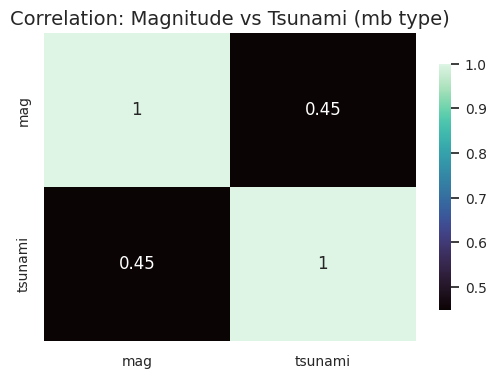

In [23]:
eq_mb = eq[eq['magType'] == 'mb'][['mag','tsunami']]
corr = eq_mb.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="mako", cbar_kws={'shrink':0.8})
plt.title("Correlation: Magnitude vs Tsunami (mb type)", fontsize=14)
plt.show()









2. Create a box plot of Facebook volume traded and closing prices, and draw reference lines for the bounds of a Tukey fence with a multiplier of 1.5. The bounds will be at Q1 - 1.5 * IQR and Q3 + 1.5 * IQR. Be sure to use the quantile() method on the data to make this easier. (Pick whichever orientation you prefer for the plot, but make sure to use subplots.)

/tmp/ipykernel_539/3527422174.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=fb['volume'], ax=axes[0], palette="pastel")
/tmp/ipykernel_539/3527422174.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=fb['close'], ax=axes[1], palette="pastel")


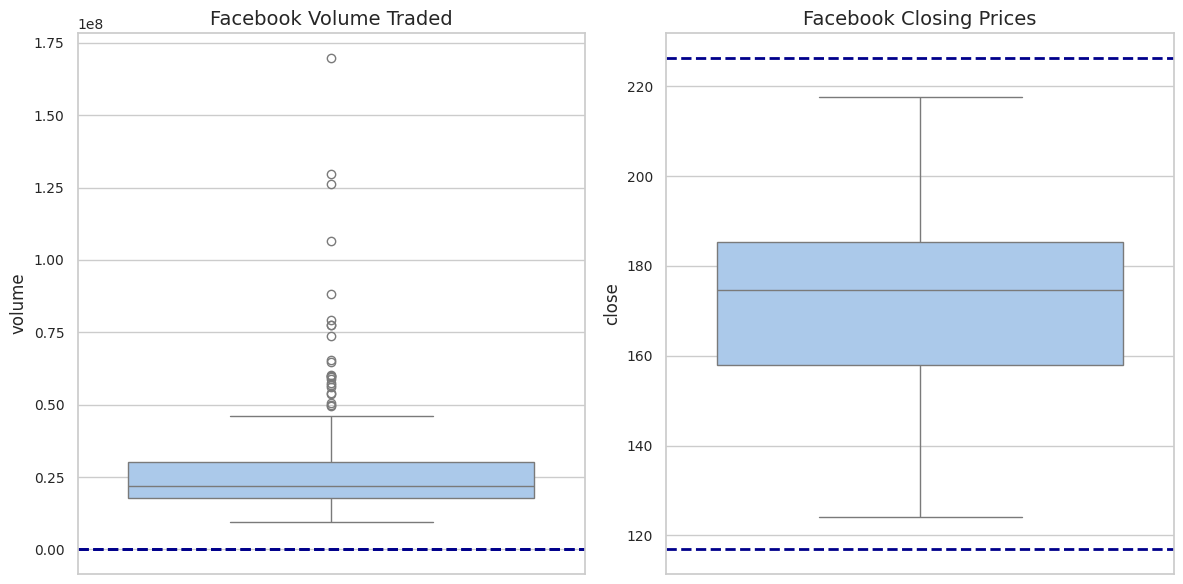

In [24]:
q1 = fb['close'].quantile(0.25)
q3 = fb['close'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

fig, axes = plt.subplots(1,2, figsize=(12,6))

sns.boxplot(y=fb['volume'], ax=axes[0], palette="pastel")
axes[0].set_title("Facebook Volume Traded")
axes[0].axhline(lower, color='darkblue', linestyle='--', label="Lower Bound")
axes[0].axhline(upper, color='darkblue', linestyle='--', label="Upper Bound")

sns.boxplot(y=fb['close'], ax=axes[1], palette="pastel")
axes[1].set_title("Facebook Closing Prices")
axes[1].axhline(lower, color='darkblue', linestyle='--', label="Lower Bound")
axes[1].axhline(upper, color='darkblue', linestyle='--', label="Upper Bound")

plt.tight_layout()
plt.show()




3. Fill in the area between the bounds in the plot from exercise #2.

/tmp/ipykernel_539/2148573827.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=fb['close'], ax=ax, palette="cubehelix")


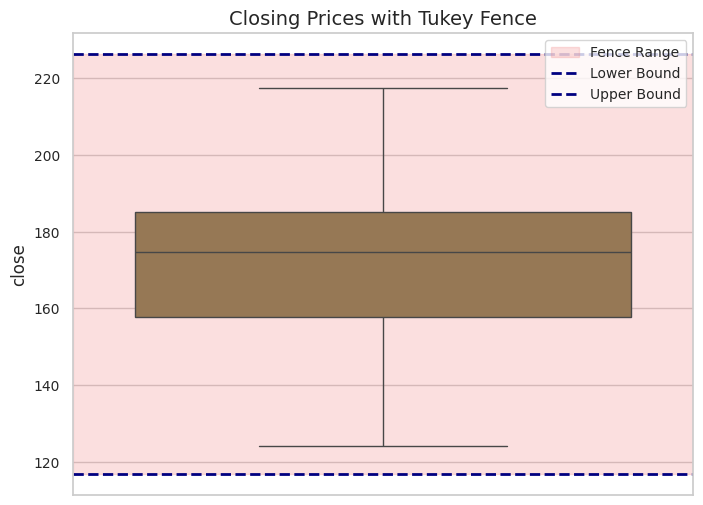

In [25]:
q1 = fb['close'].quantile(0.25)
q3 = fb['close'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(y=fb['close'], ax=ax, palette="cubehelix")
ax.set_title("Closing Prices with Tukey Fence", fontsize=14)

ax.axhspan(lower, upper, color='lightcoral', alpha=0.25, label="Fence Range")
ax.axhline(lower, color='navy', linestyle='--', label="Lower Bound")
ax.axhline(upper, color='navy', linestyle='--', label="Upper Bound")
ax.legend()
plt.show()





4. Use axvspan() to shade a rectangle from '2018-07-25' to '2018-07-31', which marks the large decline in Facebook price on a line plot of the closing price.


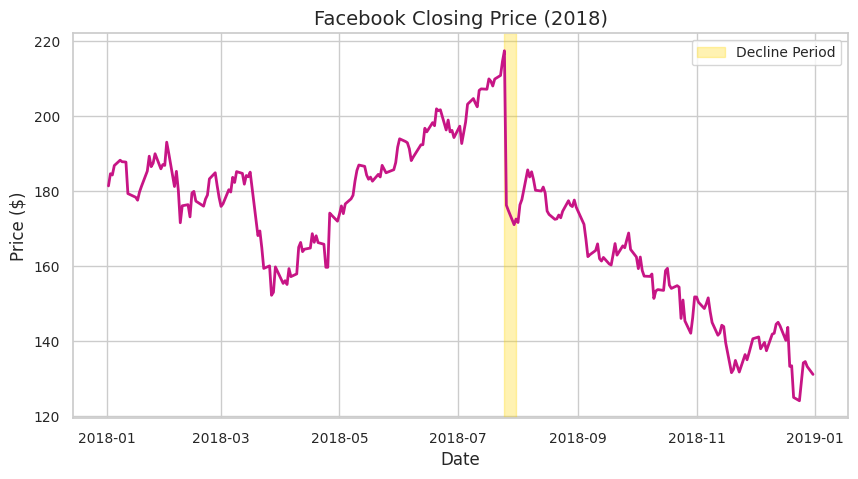

In [26]:

fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(x=fb['date'], y=fb['close'], color="mediumvioletred")
ax.set_title("Facebook Closing Price (2018)", fontsize=14)
ax.set_ylabel("Price ($)")
ax.set_xlabel("Date")
ax.axvspan(pd.Timestamp('2018-07-25'), pd.Timestamp('2018-07-31'),
           color='gold', alpha=0.3, label="Decline Period")
ax.legend()
plt.show()





5. Using the Facebook stock price data, annotate the following three events on a line plot of the closing price:

* Disappointing user growth announced after close on July 25, 2018

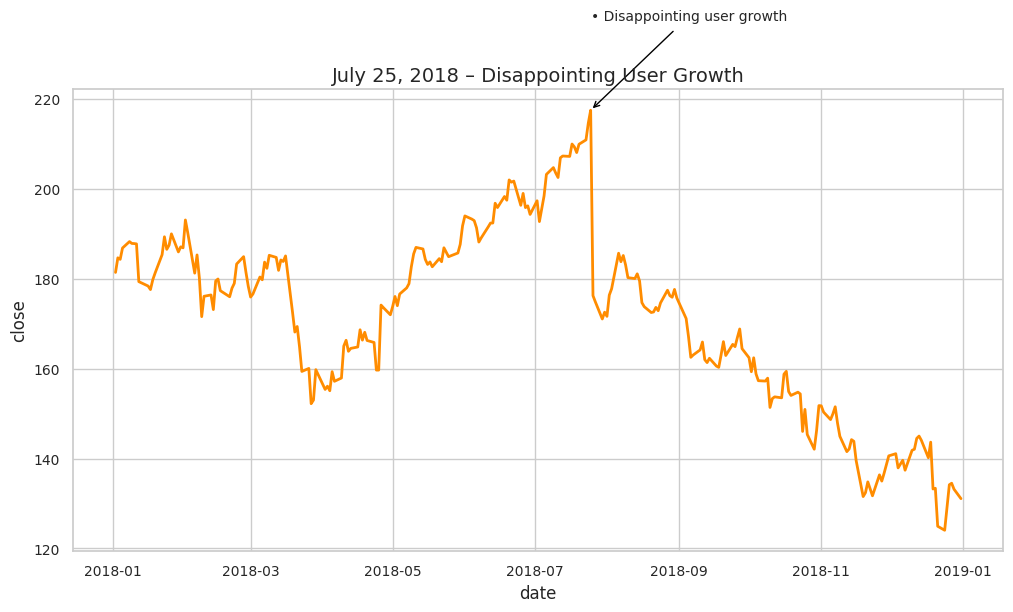

In [27]:
fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(x=fb['date'], y=fb['close'], color="darkorange")
ax.set_title("July 25, 2018 – Disappointing User Growth", fontsize=14)

date = pd.Timestamp("2018-07-25")
price = fb.loc[fb['date'] == date, 'close'].values[0]
ax.annotate("• Disappointing user growth",
            xy=(date, price),
            xytext=(date, price+20),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10, backgroundcolor="white")
plt.show()






* Cambridge Analytica story breaks on March 19, 2018 (when it affected the market)

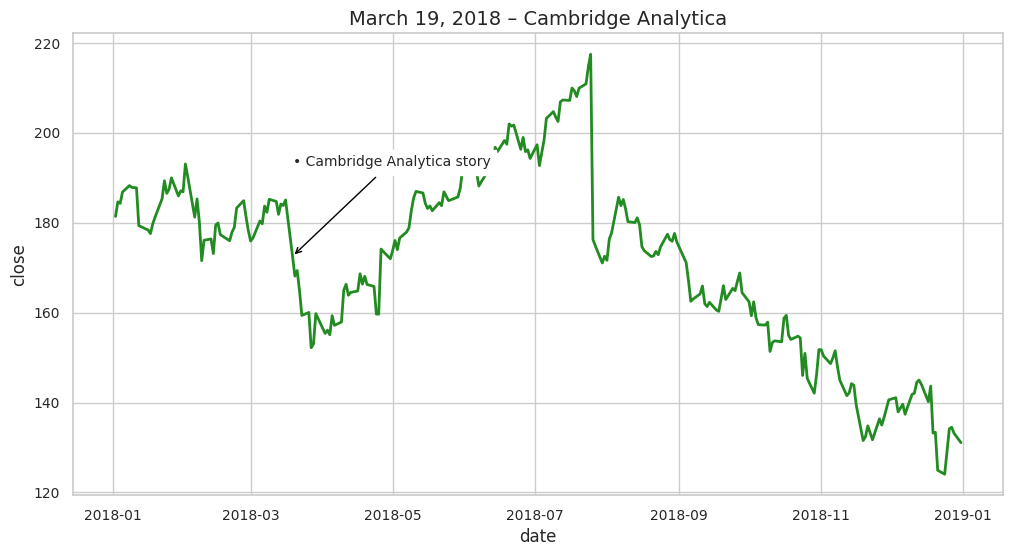

In [28]:
fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(x=fb['date'], y=fb['close'], color="forestgreen")
ax.set_title("March 19, 2018 – Cambridge Analytica", fontsize=14)

date = pd.Timestamp("2018-03-19")
price = fb.loc[fb['date'] == date, 'close'].values[0]
ax.annotate("• Cambridge Analytica story",
            xy=(date, price),
            xytext=(date, price+20),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10, backgroundcolor="white")
plt.show()



* FTC launches investigation on March 20, 2018

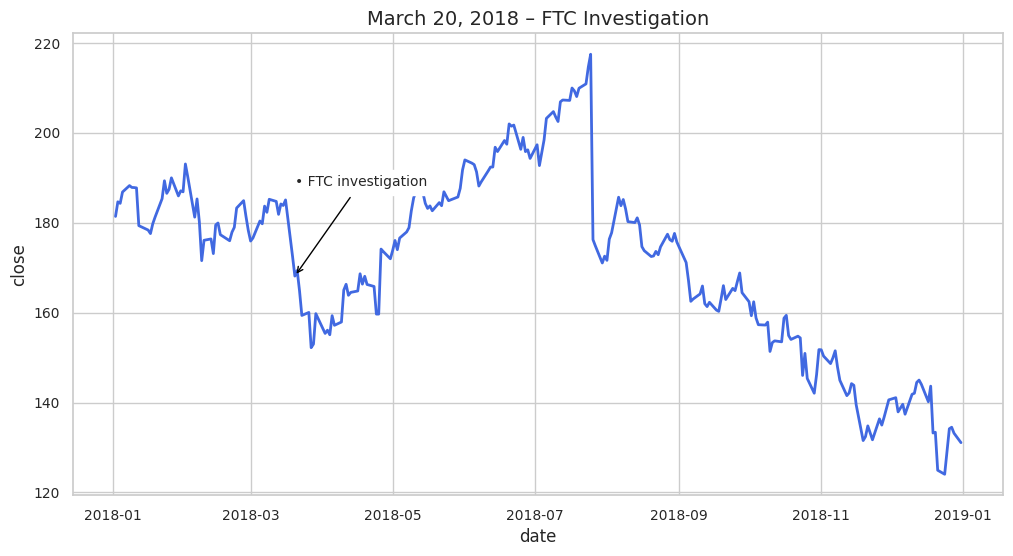

In [29]:
fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(x=fb['date'], y=fb['close'], color="royalblue")
ax.set_title("March 20, 2018 – FTC Investigation", fontsize=14)

date = pd.Timestamp("2018-03-20")
price = fb.loc[fb['date'] == date, 'close'].values[0]
ax.annotate("• FTC investigation",
            xy=(date, price),
            xytext=(date, price+20),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10, backgroundcolor="white")
plt.show()



6. Modify the reg_resid_plots() function to use a matplotlib colormap instead of cycling between two colors. Remember, for this use case, we should pick a qualitative colormap or make our own.

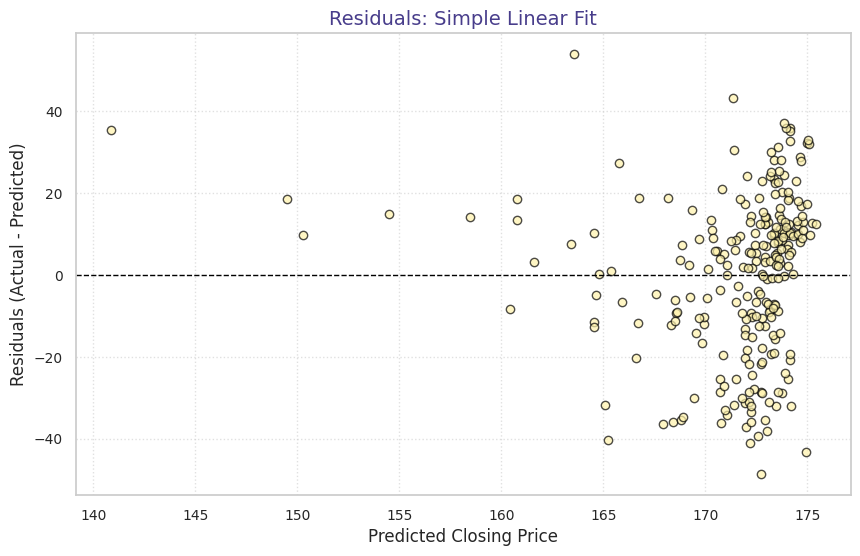

In [31]:
X = fb['volume'].values
y = fb['close'].values

coef = np.polyfit(X, y, 1)
preds = np.polyval(coef, X)
residuals = y - preds

fig, ax = plt.subplots(figsize=(10,6))

colors = sns.color_palette("Spectral", 12)
ax.scatter(preds, residuals, color=colors[5], alpha=0.7, edgecolor="black")

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.set_title("Residuals: Simple Linear Fit", fontsize=14, color="darkslateblue")
ax.set_xlabel("Predicted Closing Price", fontsize=12)
ax.set_ylabel("Residuals (Actual - Predicted)", fontsize=12)
ax.grid(True, linestyle=":", alpha=0.6)

plt.show()





#**Summary/Conclusion:** <br>
*In this activity I learned how to use Seaborn and Matplotlib to make data visualizations more clear and engaging. Guided by the procedures I practiced building heatmaps, boxplots, line plots, and residual plots, while adding highlights and annotations to tell the story behind the data.
Overall, this showed me how formatting and customization can turn raw numbers into meaningful insights that are easier to understand and present.*